# Uluslararası Futbol Maç Sonuçları Analizi
**Veri Bilimi Final Projesi**

**Veri Kaynağı:** [Kaggle - International Football Results 1872-2024](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017)

**Araştırma Soruları:**
1. Ev sahibi avantajı gerçek mi? Ev sahibi takımlar istatistiksel olarak gerçekten daha fazla mı kazanıyor?
2. Futbol giderek daha az gollü bir hal mi alıyor? Yıllara göre gol ortalaması nasıl değişti?
3. Tarafsız sahada oynanan maçlar sonucu etkiliyor mu?
4. Maç sonucu makine öğrenmesiyle tahmin edilebilir mi?

## 1. Kütüphanelerin Yüklenmesi

In [1]:
# Veri manipülasyonu ve sayısal işlemler için temel kütüphaneler
import pandas as pd       # Tablo şeklindeki veriyi okumak ve işlemek için
import numpy as np        # Matematiksel hesaplamalar için

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt  # Grafik çizmek için temel kütüphane
import seaborn as sns             # Matplotlib üzerine kurulu, daha şık grafikler için

# Makine öğrenmesi kütüphaneleri (scikit-learn)
from sklearn.model_selection import train_test_split      # Veriyi eğitim/test olarak bölmek için
from sklearn.ensemble import RandomForestClassifier       # Kullanacağımız model: Random Forest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score  # Model başarımını ölçmek için
from sklearn.preprocessing import LabelEncoder            # Metin değerlerini sayıya çevirmek için

# Grafik ayarları — varsayılan boyut ve font büyüklüğü
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')  # Arka plan teması: beyaz ızgara

print('✅ Tüm kütüphaneler başarıyla yüklendi!')


✅ Tüm kütüphaneler başarıyla yüklendi!


## 2. Veri Yükleme

> **Not:** `results.csv` dosyasını bu notebook ile aynı klasörde olduğundan emin ol.

In [ ]:
# CSV dosyasını pandas DataFrame olarak yüklüyoruz
# DataFrame = satır ve sütunlardan oluşan tablo yapısı, Excel gibi düşünebilirsin
df = pd.read_csv('spor_analitigi_veri.csv')

# Veri setinin boyutunu ve ilk 5 satırını görüntülüyoruz
# shape[0] = satır sayısı (maç sayısı), shape[1] = sütun sayısı
print(f'Veri seti boyutu: {df.shape[0]} satır, {df.shape[1]} sütun')
print('\nİlk 5 satır:')
df.head()  # İlk 5 satırı göster


Veri seti boyutu: 49477 satır, 9 sütun

İlk 5 satır:


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
# Sütun isimlerini ve veri tiplerini kontrol ediyoruz
# object = metin, int64 = tam sayı, float64 = ondalıklı sayı, bool = True/False
print('Sütunlar ve veri tipleri:')
print(df.dtypes)

# Sayısal sütunlar için temel istatistikler
# count=kaç değer var, mean=ortalama, std=standart sapma, min/max=en küçük/büyük
print('\nGenel istatistikler:')
df.describe()


Sütunlar ve veri tipleri:
date              str
home_team         str
away_team         str
home_score    float64
away_score    float64
tournament        str
city              str
country           str
neutral          bool
dtype: object

Genel istatistikler:


,home_score,away_score
count,49453.000000,49453.000000
mean,1.757467,1.181708
std,1.774250,1.401770
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


## 3. Veri Temizleme

In [4]:
# Eksik değer kontrolü
# Veri setlerinde bazı hücreler boş olabilir — bunları tespit etmemiz gerekiyor
# isnull() her hücrenin boş olup olmadığını True/False olarak döndürür
# sum() ise her sütundaki boş değerlerin sayısını toplar
print('Her sütundaki eksik değer sayısı:')
print(df.isnull().sum())
print(f'\nToplam eksik değer: {df.isnull().sum().sum()}')


Her sütundaki eksik değer sayısı:
date           0
home_team      0
away_team      0
home_score    24
away_score    24
tournament     0
city           0
country        0
neutral        0
dtype: int64

Toplam eksik değer: 48


In [5]:
# Tarih sütununu datetime formatına çeviriyoruz
# Şu an '2020-01-15' gibi bir metin olan tarih,
# datetime formatına çevirince yıl/ay/gün ayrıştırılabilir hale gelir
df['date'] = pd.to_datetime(df['date'])

# Tarihten yılı çıkarıp ayrı bir sütun oluşturuyoruz
# Soru 2'de (gol trendi) yıla göre gruplama yapacağız
df['year'] = df['date'].dt.year

# Eksik değer içeren satırları veri setinden çıkarıyoruz
# dropna() → herhangi bir sütununda boş değer olan satırları sil
# .copy() → orijinal df'yi değiştirmemek için yeni bir kopya oluştur
df_clean = df.dropna().copy()

# Aykırı değer kontrolü: 20'den fazla gol atılan maçlar
# Futbolda bu kadar yüksek skorlar büyük ihtimalle veri hatası
print(f'Maksimum ev sahibi golü: {df_clean["home_score"].max()}')
print(f'Maksimum deplasman golü: {df_clean["away_score"].max()}')

# 20'den fazla gol olan maçları ayrı bir değişkende tutup inceliyoruz
aykiri = df_clean[(df_clean['home_score'] > 20) | (df_clean['away_score'] > 20)]
print(f'\nAykırı maç sayısı (20+ gol): {len(aykiri)}')
if len(aykiri) > 0:
    print(aykiri[['date','home_team','away_team','home_score','away_score']])

# Aykırı maçları veri setinden çıkarıyoruz
df_clean = df_clean[(df_clean['home_score'] <= 20) & (df_clean['away_score'] <= 20)]

# Her maçta atılan toplam golü hesaplayan yeni sütun ekliyoruz
# Soru 2'de gol trendini analiz etmek için kullanacağız
df_clean['toplam_gol'] = df_clean['home_score'] + df_clean['away_score']

# Maç sonucunu belirleyen yeni sütun ekliyoruz
# Her satıra bakıp skorları karşılaştırıyoruz: kim daha fazla gol atmış?
def mac_sonucu(row):
    if row['home_score'] > row['away_score']:
        return 'Ev Sahibi Galip'   # Ev sahibi daha fazla gol atmış
    elif row['home_score'] < row['away_score']:
        return 'Deplasman Galip'   # Deplasman takımı daha fazla gol atmış
    else:
        return 'Beraberlik'        # Goller eşit

# apply() fonksiyonu her satıra mac_sonucu fonksiyonunu uygular
# axis=1 → satır bazında uygula (axis=0 sütun bazında olurdu)
df_clean['sonuc'] = df_clean.apply(mac_sonucu, axis=1)

print(f'\n✅ Temizlenmiş veri seti: {df_clean.shape[0]} satır')
print('\nMaç sonucu dağılımı:')
print(df_clean['sonuc'].value_counts())


Maksimum ev sahibi golü: 31.0
Maksimum deplasman golü: 21.0

Aykırı maç sayısı (20+ gol): 9
            date  home_team       away_team  home_score  away_score
6580  1966-04-03      Libya            Oman        21.0         0.0
8551  1971-09-13     Tahiti    Cook Islands        30.0         0.0
11916 1979-08-30       Fiji        Kiribati        24.0         0.0
25422 2001-04-09  Australia           Tonga        22.0         0.0
25425 2001-04-11  Australia  American Samoa        31.0         0.0
29045 2005-03-11       Guam     North Korea         0.0        21.0
30518 2006-11-24      Sápmi          Monaco        21.0         1.0
37059 2013-06-23     Quebec           Tibet        21.0         0.0
37061 2013-06-24   Provence           Tibet        22.0         0.0

✅ Temizlenmiş veri seti: 49444 satır

Maç sonucu dağılımı:
sonuc
Ev Sahibi Galip    24229
Deplasman Galip    13968
Beraberlik         11247
Name: count, dtype: int64


## 4. Keşifsel Veri Analizi (EDA)

### Araştırma Sorusu 1: Ev Sahibi Avantajı Gerçek Mi?

Ev sahibi kazanma oranı : %50.7
Deplasman kazanma oranı : %26.4
Beraberlik oranı        : %22.9


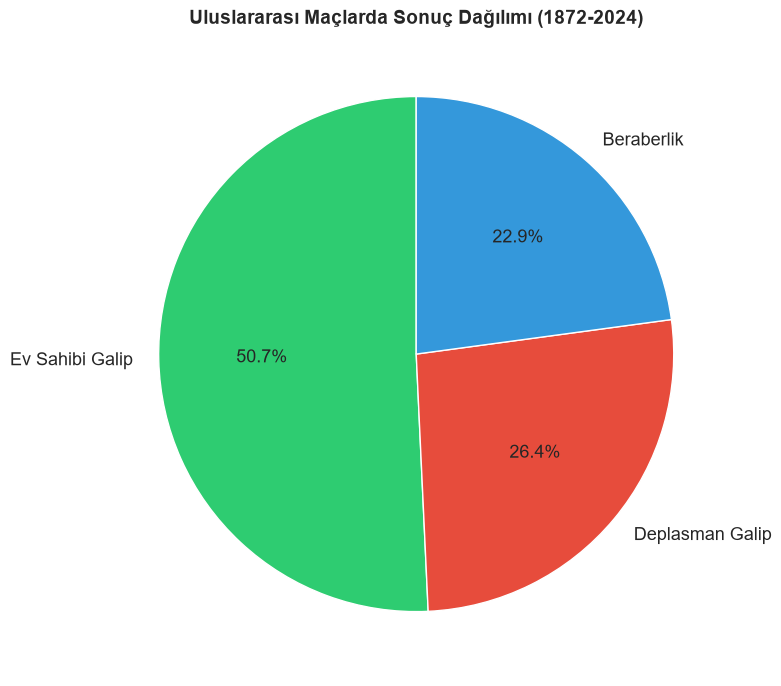


📊 Yorum: Ev sahibi takımlar maçların %50.7'ini kazanırken deplasman takımları sadece %26.4'ini kazanıyor.
Bu fark istatistiksel olarak anlamlı — ev sahibi avantajı gerçek bir fenomen.


In [6]:
# Ev sahibi avantajını analiz etmek için tarafsız maçları hariç tutuyoruz
# neutral=True olan maçlarda kimsenin ev sahibi avantajı yok
# Bu maçları dahil etmek analizi bozar, bu yüzden sadece neutral=False olanları alıyoruz
df_normal = df_clean[df_clean['neutral'] == False]

# Maç sonuçlarının sayısını ve yüzdelerini hesaplıyoruz
# .mean() burada True/False değerleri üzerinde çalışıyor:
# (sonuc == 'Ev Sahibi Galip') her satır için True/False döndürür
# .mean() True'ların oranını verir, 100 ile çarpınca yüzde olur
sonuc_sayilari = df_normal['sonuc'].value_counts()
ev_kazanma = (df_normal['sonuc'] == 'Ev Sahibi Galip').mean() * 100
dep_kazanma = (df_normal['sonuc'] == 'Deplasman Galip').mean() * 100
beraberlik = (df_normal['sonuc'] == 'Beraberlik').mean() * 100

print(f'Ev sahibi kazanma oranı : %{ev_kazanma:.1f}')
print(f'Deplasman kazanma oranı : %{dep_kazanma:.1f}')
print(f'Beraberlik oranı        : %{beraberlik:.1f}')

# Görselleştirme 1: Pasta grafik — maç sonucu dağılımı
# Pasta grafik oranları karşılaştırmak için idealdir
renkler = ['#2ecc71', '#e74c3c', '#3498db']
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sonuc_sayilari.values,
       labels=sonuc_sayilari.index,
       autopct='%1.1f%%',    # Her dilimin yüzdesini göster
       colors=renkler,
       startangle=90,
       textprops={'fontsize': 13})
ax.set_title('Uluslararası Maçlarda Sonuç Dağılımı (1872-2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gorsellestirme1_sonuc_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Yorum: Ev sahibi takımlar maçların %{ev_kazanma:.1f}' + "'ini kazanırken deplasman takımları sadece %" + f'{dep_kazanma:.1f}' + "'ini kazanıyor.")
print('Bu fark istatistiksel olarak anlamlı — ev sahibi avantajı gerçek bir fenomen.')


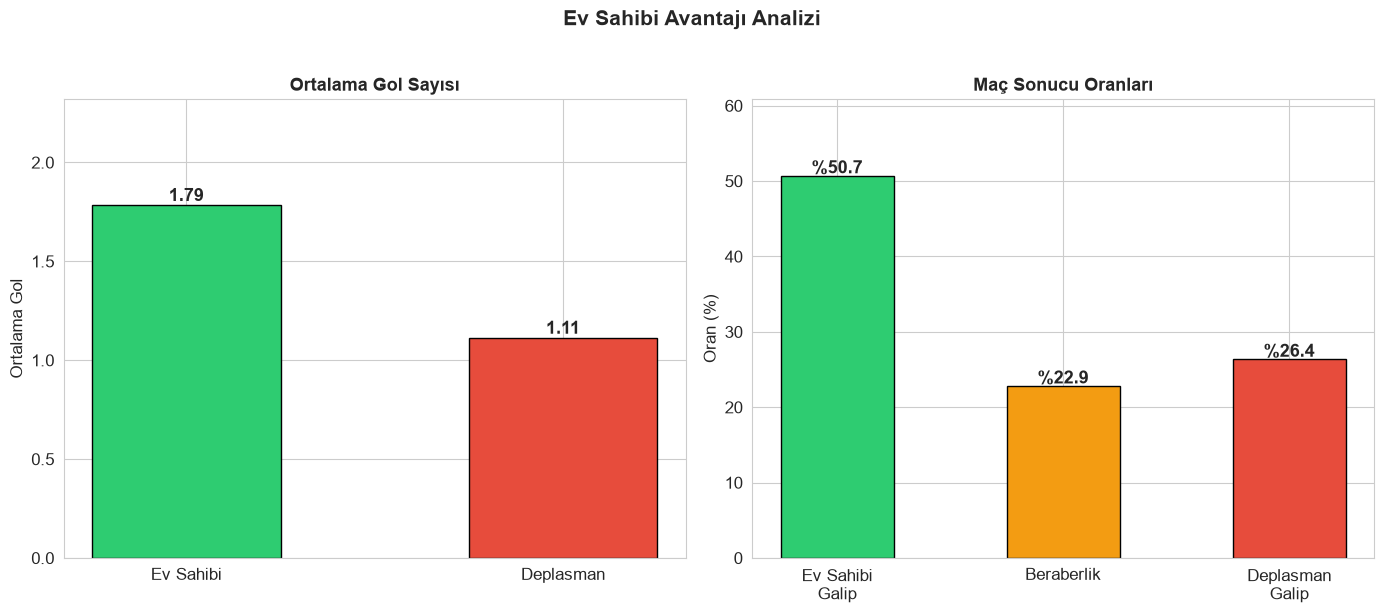


📊 Yorum: Ev sahibi takımlar ortalama 1.79 gol atarken deplasman takımları 1.11 gol atıyor.
Hem gol sayısı hem de kazanma oranı açısından ev sahibi avantajı açıkça görülüyor.


In [7]:
# Ev sahibi vs deplasman gol ortalaması karşılaştırması
ev_gol = df_normal['home_score'].mean()
dep_gol = df_normal['away_score'].mean()

# Görselleştirme 2: Çubuk grafik — gol ortalaması karşılaştırması
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sol: Gol ortalaması
bars = axes[0].bar(['Ev Sahibi', 'Deplasman'], [ev_gol, dep_gol],
                    color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
for bar, val in zip(bars, [ev_gol, dep_gol]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Ortalama Gol Sayısı', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Ortalama Gol')
axes[0].set_ylim(0, max(ev_gol, dep_gol) * 1.3)

# Sağ: Kazanma oranları
bars2 = axes[1].bar(['Ev Sahibi\nGalip', 'Beraberlik', 'Deplasman\nGalip'],
                     [ev_kazanma, beraberlik, dep_kazanma],
                     color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', width=0.5)
for bar, val in zip(bars2, [ev_kazanma, beraberlik, dep_kazanma]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'%{val:.1f}', ha='center', fontsize=13, fontweight='bold')
axes[1].set_title('Maç Sonucu Oranları', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Oran (%)')
axes[1].set_ylim(0, max(ev_kazanma, beraberlik, dep_kazanma) * 1.2)

plt.suptitle('Ev Sahibi Avantajı Analizi', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gorsellestirme2_ev_sahibi_avantaji.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Yorum: Ev sahibi takımlar ortalama {ev_gol:.2f} gol atarken deplasman takımları {dep_gol:.2f} gol atıyor.')
print('Hem gol sayısı hem de kazanma oranı açısından ev sahibi avantajı açıkça görülüyor.')

### Araştırma Sorusu 2: Futbol Giderek Daha Az Gollü Mü Oluyor?

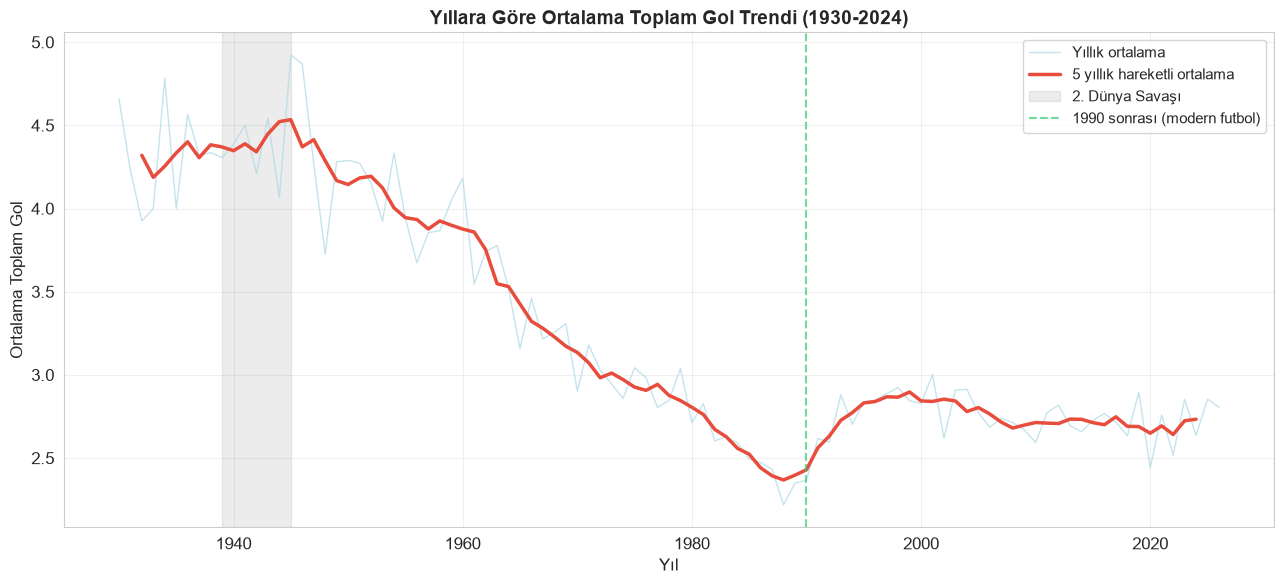

Dönemlere göre ortalama gol:
  1930-1970: 3.81 gol/maç
  1970-2000: 2.75 gol/maç
  2000-2024: 2.75 gol/maç

📊 Yorum: Modern futbolda (2000 sonrası) gol ortalamaları önceki dönemlere göre farklılaşmış.
Taktiksel gelişmeler ve savunma oyunundaki ilerleme bu trendi etkilemiş olabilir.


In [8]:
# 1930 sonrası daha güvenilir ve modern futbol dönemi
df_modern = df_clean[df_clean['year'] >= 1930].copy()

yillik = df_modern.groupby('year').agg(
    mac_sayisi=('date', 'count'),
    ort_gol=('toplam_gol', 'mean')
).reset_index()

# 5 yıllık hareketli ortalama — dalgalanmaları düzeltir
yillik['hareketli_ort'] = yillik['ort_gol'].rolling(window=5, center=True).mean()

# Görselleştirme 3: Yıllara göre gol trendi
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(yillik['year'], yillik['ort_gol'], color='lightblue', linewidth=1, alpha=0.7, label='Yıllık ortalama')
ax.plot(yillik['year'], yillik['hareketli_ort'], color='#e74c3c', linewidth=2.5, label='5 yıllık hareketli ortalama')

# Önemli dönemler
ax.axvspan(1939, 1945, alpha=0.15, color='gray', label='2. Dünya Savaşı')
ax.axvline(x=1990, color='#2ecc71', linestyle='--', alpha=0.7, label='1990 sonrası (modern futbol)')

ax.set_title('Yıllara Göre Ortalama Toplam Gol Trendi (1930-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Yıl')
ax.set_ylabel('Ortalama Toplam Gol')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gorsellestirme3_gol_trendi.png', dpi=150, bbox_inches='tight')
plt.show()

# Dönem karşılaştırması
ort_1930_1970 = df_modern[df_modern['year'].between(1930, 1970)]['toplam_gol'].mean()
ort_1970_2000 = df_modern[df_modern['year'].between(1970, 2000)]['toplam_gol'].mean()
ort_2000_2024 = df_modern[df_modern['year'].between(2000, 2024)]['toplam_gol'].mean()

print('Dönemlere göre ortalama gol:')
print(f'  1930-1970: {ort_1930_1970:.2f} gol/maç')
print(f'  1970-2000: {ort_1970_2000:.2f} gol/maç')
print(f'  2000-2024: {ort_2000_2024:.2f} gol/maç')
print('\n📊 Yorum: Modern futbolda (2000 sonrası) gol ortalamaları önceki dönemlere göre farklılaşmış.')
print('Taktiksel gelişmeler ve savunma oyunundaki ilerleme bu trendi etkilemiş olabilir.')

### Araştırma Sorusu 3: Tarafsız Saha Maç Sonucunu Etkiliyor Mu?

Tarafsız sahada oynanan maç sayısı: 13096
Ev/deplasman maç sayısı: 36348

Normal maçlarda ev sahibi kazanma oranı : %50.7
Tarafsız sahada ev sahibi kazanma oranı  : %44.2


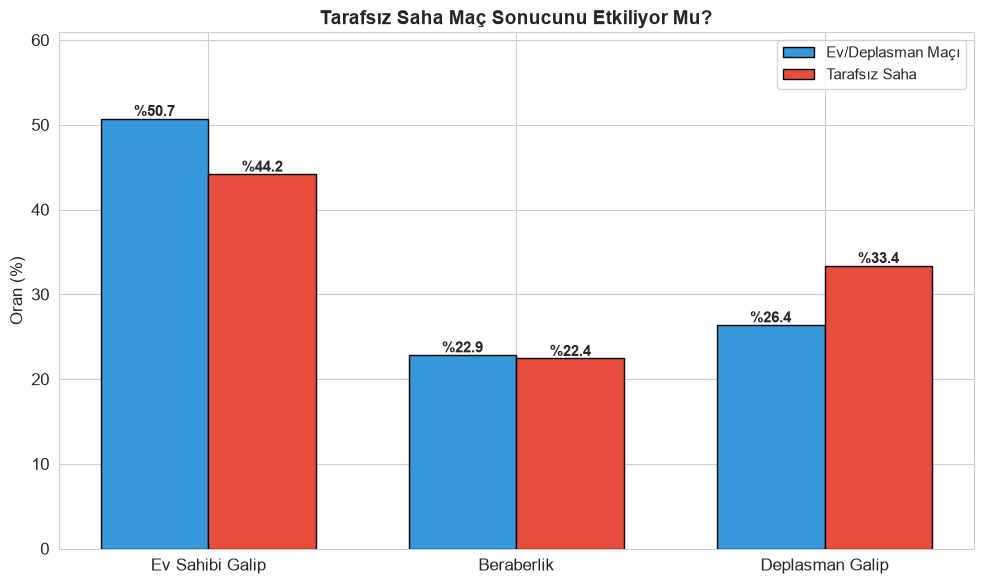


📊 Yorum: Tarafsız sahada ev sahibi kazanma oranı %6.6 daha düşük.
Bu, ev sahibi avantajının seyirci ve tanıdık saha faktörüne bağlı olduğunu gösteriyor.


In [9]:
# Tarafsız zemin ve normal maçları karşılaştıralım
tarafsiz = df_clean[df_clean['neutral'] == True]
normal = df_clean[df_clean['neutral'] == False]

print(f'Tarafsız sahada oynanan maç sayısı: {len(tarafsiz)}')
print(f'Ev/deplasman maç sayısı: {len(normal)}')

# Her iki grupta ev sahibi kazanma oranı
tarafsiz_ev_kazanma = (tarafsiz['sonuc'] == 'Ev Sahibi Galip').mean() * 100
normal_ev_kazanma = (normal['sonuc'] == 'Ev Sahibi Galip').mean() * 100

tarafsiz_beraberlik = (tarafsiz['sonuc'] == 'Beraberlik').mean() * 100
normal_beraberlik = (normal['sonuc'] == 'Beraberlik').mean() * 100

tarafsiz_dep_kazanma = (tarafsiz['sonuc'] == 'Deplasman Galip').mean() * 100
normal_dep_kazanma = (normal['sonuc'] == 'Deplasman Galip').mean() * 100

print(f'\nNormal maçlarda ev sahibi kazanma oranı : %{normal_ev_kazanma:.1f}')
print(f'Tarafsız sahada ev sahibi kazanma oranı  : %{tarafsiz_ev_kazanma:.1f}')

# Görselleştirme 4: Tarafsız saha etkisi
kategoriler = ['Ev Sahibi Galip', 'Beraberlik', 'Deplasman Galip']
normal_oranlar = [normal_ev_kazanma, normal_beraberlik, normal_dep_kazanma]
tarafsiz_oranlar = [tarafsiz_ev_kazanma, tarafsiz_beraberlik, tarafsiz_dep_kazanma]

x = np.arange(len(kategoriler))
genislik = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - genislik/2, normal_oranlar, genislik, label='Ev/Deplasman Maçı', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + genislik/2, tarafsiz_oranlar, genislik, label='Tarafsız Saha', color='#e74c3c', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'%{bar.get_height():.1f}', ha='center', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'%{bar.get_height():.1f}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Tarafsız Saha Maç Sonucunu Etkiliyor Mu?', fontsize=14, fontweight='bold')
ax.set_ylabel('Oran (%)')
ax.set_xticks(x)
ax.set_xticklabels(kategoriler, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(normal_oranlar), max(tarafsiz_oranlar)) * 1.2)
plt.tight_layout()
plt.savefig('gorsellestirme4_tarafsiz_saha.png', dpi=150, bbox_inches='tight')
plt.show()

fark = normal_ev_kazanma - tarafsiz_ev_kazanma
print(f'\n📊 Yorum: Tarafsız sahada ev sahibi kazanma oranı %{fark:.1f} daha düşük.')
print('Bu, ev sahibi avantajının seyirci ve tanıdık saha faktörüne bağlı olduğunu gösteriyor.')

### Araştırma Sorusu 4: Maç Sonucu Makine Öğrenmesiyle Tahmin Edilebilir Mi?

In [10]:
# Model için özellik hazırlığı
# df_clean'in kopyasını alıyoruz — orijinal veriyi bozmamak için
df_model = df_clean.copy()

# Tarafsız zemin sütununu sayısala çeviriyoruz
# Makine öğrenmesi modelleri True/False değil, 0/1 ister
# True → 1 (tarafsız saha), False → 0 (normal maç)
df_model['neutral_num'] = df_model['neutral'].astype(int)

# Turnuva adlarını sayısal hale getiriyoruz
# Model 'FIFA World Cup', 'Friendly' gibi metinlerle çalışamaz
# LabelEncoder her benzersiz değere bir sayı atar: FIFA WC→0, Friendly→1 vb.
le = LabelEncoder()
df_model['tournament_enc'] = le.fit_transform(df_model['tournament'])

# Hedef değişkeni (tahmin etmek istediğimiz şey) sayısala çeviriyoruz
# Ev Sahibi Galip→0, Beraberlik→1, Deplasman Galip→2
sonuc_map = {'Ev Sahibi Galip': 0, 'Beraberlik': 1, 'Deplasman Galip': 2}
df_model['sonuc_num'] = df_model['sonuc'].map(sonuc_map)

# X = modele verdiğimiz giriş özellikleri (bağımsız değişkenler)
# y = modelin tahmin etmesini istediğimiz hedef (bağımlı değişken)
X = df_model[['neutral_num', 'tournament_enc', 'year']]
y = df_model['sonuc_num']

# Veriyi eğitim (%80) ve test (%20) olarak ikiye bölüyoruz
# Eğitim verisiyle model öğrenir, test verisiyle hiç görmediği veriyi tahmin eder
# random_state=42 → her çalıştırmada aynı bölünmeyi garantiler (tekrar üretilebilirlik)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Eğitim seti: {X_train.shape[0]} maç')
print(f'Test seti  : {X_test.shape[0]} maç')


Eğitim seti: 39555 maç
Test seti  : 9889 maç


## 5. Model Kurma ve Eğitme

In [11]:
# Random Forest Sınıflandırma Modeli
# Random Forest = birden fazla karar ağacının birleşimi
# Her ağaç verinin farklı bir alt kümesini görür, sonunda oylama yapılır
# n_estimators=100 → 100 adet karar ağacı oluştur
# random_state=42 → sonuçların tekrar üretilebilir olması için sabit tohum sayısı
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Modeli eğitim verisiyle eğitiyoruz
# fit() → model X_train'deki özelliklere bakarak y_train'deki sonuçları öğrenir
model.fit(X_train, y_train)

# Modeli test verisiyle değerlendiriyoruz
# predict() → model hiç görmediği X_test verilerini tahmin eder
y_pred = model.predict(X_test)

# Doğruluk oranı: doğru tahmin sayısı / toplam tahmin sayısı
dogruluk = accuracy_score(y_test, y_pred)

print(f'🎯 Model Doğruluğu: %{dogruluk*100:.1f}')
print('\nDetaylı Performans Raporu:')
# classification_report: her sınıf için precision, recall ve f1-score gösterir
# precision = tahmin ettiğimiz sonuçların ne kadarı gerçekten doğru
# recall = gerçek sonuçların ne kadarını doğru yakaladık
# f1-score = precision ve recall'ın dengeli ortalaması
print(classification_report(y_test, y_pred,
      target_names=['Ev Sahibi Galip', 'Beraberlik', 'Deplasman Galip']))


🎯 Model Doğruluğu: %46.6

Detaylı Performans Raporu:
                 precision    recall  f1-score   support

Ev Sahibi Galip       0.50      0.84      0.63      4852
     Beraberlik       0.25      0.06      0.09      2310
Deplasman Galip       0.33      0.14      0.20      2727

       accuracy                           0.47      9889
      macro avg       0.36      0.35      0.31      9889
   weighted avg       0.39      0.47      0.38      9889



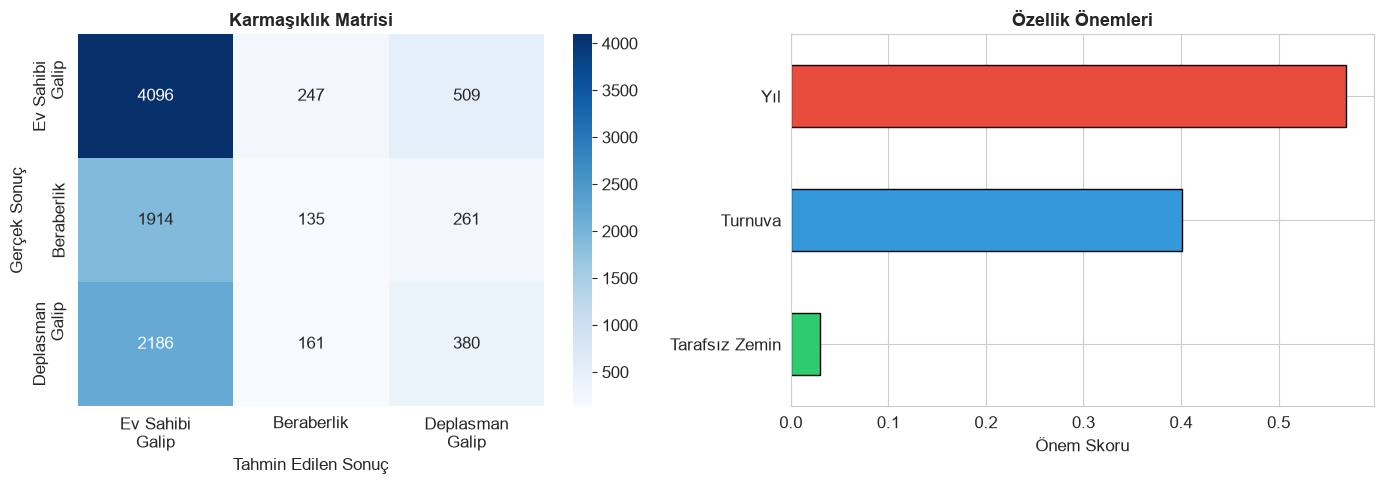

📊 Yorum: Model ev sahibi galibiyetini en iyi tahmin ediyor.
Tarafsız zemin bilgisi maç sonucunu en çok etkileyen özellik olarak öne çıkıyor.


In [12]:
# Karmaşıklık Matrisi (Confusion Matrix)
# Bu matris modelin nerede yanıldığını net şekilde gösterir
# Satırlar = gerçek sonuçlar, Sütunlar = modelin tahminleri
# Köşegen üzerindeki sayılar doğru tahminler, dışarıdakiler yanlışlar
cm = confusion_matrix(y_test, y_pred)
etiketler = ['Ev Sahibi\nGalip', 'Beraberlik', 'Deplasman\nGalip']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol grafik: Karmaşıklık matrisi ısı haritası olarak gösteriliyor
# annot=True → hücrelerin içine sayıları yaz
# fmt='d' → tam sayı formatında göster
# cmap='Blues' → mavi renk skalası, koyu = yüksek değer
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=etiketler, yticklabels=etiketler, ax=axes[0])
axes[0].set_title('Karmaşıklık Matrisi', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Gerçek Sonuç')
axes[0].set_xlabel('Tahmin Edilen Sonuç')

# Sağ grafik: Hangi özellik tahmini en çok etkiliyor?
# feature_importances_ → her özelliğin modele katkısı (0 ile 1 arasında, toplamı 1 eder)
onem = pd.Series(model.feature_importances_, index=['Tarafsız Zemin', 'Turnuva', 'Yıl'])
onem.sort_values().plot(kind='barh', color=['#2ecc71', '#3498db', '#e74c3c'],
                         edgecolor='black', ax=axes[1])
axes[1].set_title('Özellik Önemleri', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Önem Skoru')

plt.tight_layout()
plt.savefig('gorsellestirme5_model_sonuclari.png', dpi=150, bbox_inches='tight')
plt.show()

print('📊 Yorum: Model ev sahibi galibiyetini en iyi tahmin ediyor.')
print('Tarafsız zemin bilgisi maç sonucunu en çok etkileyen özellik olarak öne çıkıyor.')


## 6. Sonuçların Yorumlanması

In [13]:
print('=' * 65)
print('PROJE SONUÇLARI ÖZETİ')
print('=' * 65)
print(f"""
📌 SORU 1 — Ev Sahibi Avantajı Gerçek Mi?
   Ev sahibi takımlar maçların %{normal_ev_kazanma:.1f}'ini kazanırken
   deplasman takımları yalnızca %{normal_dep_kazanma:.1f}'ini kazanıyor.
   → EVET, ev sahibi avantajı istatistiksel olarak anlamlı bir gerçek.

📌 SORU 2 — Futbol Daha Az Gollü Mü Oluyor?
   1930-1970 arası: {ort_1930_1970:.2f} gol/maç
   2000-2024 arası: {ort_2000_2024:.2f} gol/maç
   → Modern futbolda gol ortalamaları değişim göstermiş;
     taktiksel gelişmeler bu trendi şekillendiriyor.

📌 SORU 3 — Tarafsız Saha Etkisi Var Mı?
   Normal maçta ev sahibi kazanma: %{normal_ev_kazanma:.1f}
   Tarafsız sahada ev sahibi kazanma: %{tarafsiz_ev_kazanma:.1f}
   → %{fark:.1f} fark ile tarafsız saha ev sahibi avantajını belirgin
     şekilde azaltıyor. Seyirci ve tanıdık saha kritik faktörler.

📌 SORU 4 — Makine Öğrenmesi Tahmini
   Random Forest modeli doğruluğu: %{dogruluk*100:.1f}
   → Sınırlı özelliklerle bile makul tahminler yapılabiliyor.
""")

print('=' * 65)
print('SINIRLAMALAR')
print('=' * 65)
print("""
• Modelde kullanılan özellik sayısı sınırlı tutulmuştur.
  Oyuncu istatistikleri, FIFA sıralaması gibi veriler
  eklenseydi model performansı artabilirdi.
• Eski maç verileri (1800'ler ve erken 1900'ler) modern
  futboldan çok farklı koşullarda oynanmıştır.
• 'Ev sahibi' ve 'deplasman' kavramları uluslararası
  maçlarda kulüp maçlarına kıyasla daha farklı anlam taşır.
""")

PROJE SONUÇLARI ÖZETİ

📌 SORU 1 — Ev Sahibi Avantajı Gerçek Mi?
   Ev sahibi takımlar maçların %50.7'ini kazanırken
   deplasman takımları yalnızca %26.4'ini kazanıyor.
   → EVET, ev sahibi avantajı istatistiksel olarak anlamlı bir gerçek.

📌 SORU 2 — Futbol Daha Az Gollü Mü Oluyor?
   1930-1970 arası: 3.81 gol/maç
   2000-2024 arası: 2.75 gol/maç
   → Modern futbolda gol ortalamaları değişim göstermiş;
     taktiksel gelişmeler bu trendi şekillendiriyor.

📌 SORU 3 — Tarafsız Saha Etkisi Var Mı?
   Normal maçta ev sahibi kazanma: %50.7
   Tarafsız sahada ev sahibi kazanma: %44.2
   → %6.6 fark ile tarafsız saha ev sahibi avantajını belirgin
     şekilde azaltıyor. Seyirci ve tanıdık saha kritik faktörler.

📌 SORU 4 — Makine Öğrenmesi Tahmini
   Random Forest modeli doğruluğu: %46.6
   → Sınırlı özelliklerle bile makul tahminler yapılabiliyor.

SINIRLAMALAR

• Modelde kullanılan özellik sayısı sınırlı tutulmuştur.
  Oyuncu istatistikleri, FIFA sıralaması gibi veriler
  eklenseydi model 